# Accelerating star

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.models import KeplerModel

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [3]:
np.random.seed(42)

In [4]:
source_id = 6199395656645840384  # HD 135344 A
primary_mass = (2.2, 0.1)  # (Msun)

In [5]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR4')


----------------
Epoch astrometry
----------------

Gaia release: DR4
Reference epoch: 2017.5

Primary mass (Msun): 2.20 +/- 0.10


In [6]:
star_param = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 6199395656645840384

INFO: Query finished. [astroquery.utils.tap.core]

RA = 228.954 deg +/- 0.038 mas
Dec = -37.149 deg +/- 0.026 mas
Parallax = 7.411 +/- 0.040 mas
Proper motion in RA = -18.738 +/- 0.051 mas/yr
Proper motion in Dec = -24.008 +/- 0.035 mas/yr
G-band magnitude = 7.748
Pseudocolor = 1.73 um-1

UWE = 1.96
RUWE = 0.95
Astrometric excess noise (mas) = 0.2075 +/- 0.0103
Non single star = 0


In [7]:
mass_2 = 0.05  # (Msun)
flux_ratio = 0.0

In [8]:
model_param = {
    'ecc': 0.0,
    'tau': 0.5,
    'inc': np.radians(30.),
    'aop': np.radians(0.),
    'pan': np.radians(90.),
    'sma': 7.,
}

In [9]:
model_param = epoch_astrom.simulate_data(
    model_param=model_param,
    mass_2=mass_2,
    flux_ratio=flux_ratio,
    occ_rate=None,
    sigma_per_ccd=None,
    csv_out=None,
)


-------------
Simulate data
-------------

System type: binary

Primary mass (Msun): 2.20 +/- 0.10

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Additional parameters:
   - Primary mass (Msun) = 2.20
   - Companion mass (Msun) = 5.00e-02
   - Mass ratio = 2.27e-02
   - Flux ratio = 0.00e+00
   - Relative semi-major axis (au) = 7.00

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 0.000
   - Dec offset (mas) = 0.000
   - Parallax (mas) = 7.411
   - Proper motion in RA (mas/yr) = -18.738
   - Proper motion in Dec (mas/yr) = -24.008

---------------------
Calculate orbit model
---------------------

Orbit parameters:
   - Period (days) = 4509.683
   - Eccentricity = 0.000
   - Relative time of periastron = 0.500
   - Semi-major axis (mas) = 51.874
   - Inclination (deg) = 30.000
   - Argument of periastron (deg) = 0.000
   - PA of ascending node (deg) = 90.000

Applying AL bia

In [10]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Binary star (7 parameters)
--------------------------

Reduced chi^2 = 1.919
RUWE = 1.385
F2 estimator = 4.934
Inflation factor = 1.391
Significance dmu/dt = 14.935

Best-fit parameters:
   - RA offset = 1.145 +/- 0.025 mas
   - Dec offset = -0.046 +/- 0.019 mas
   - Parallax = 7.421 +/- 0.019 mas
   - mu in RA = -18.736 +/- 0.011 mas/yr
   - mu in Dec = -24.404 +/- 0.006 mas/yr
   - dmu/dt in RA = -0.248 +/- 0.017 mas/yr^2
   - dmu/dt in Dec = 0.015 +/- 0.008 mas/yr^2
   - PM acceleration in RA (mas/yr^2) = -0.248
   - PM acceleration in Dec (mas/yr^2) = 0.015
   - PM acceleration in RA (mas/yr^2) = -0.248
   - PM acceleration in Dec (mas/yr^2) = 0.015


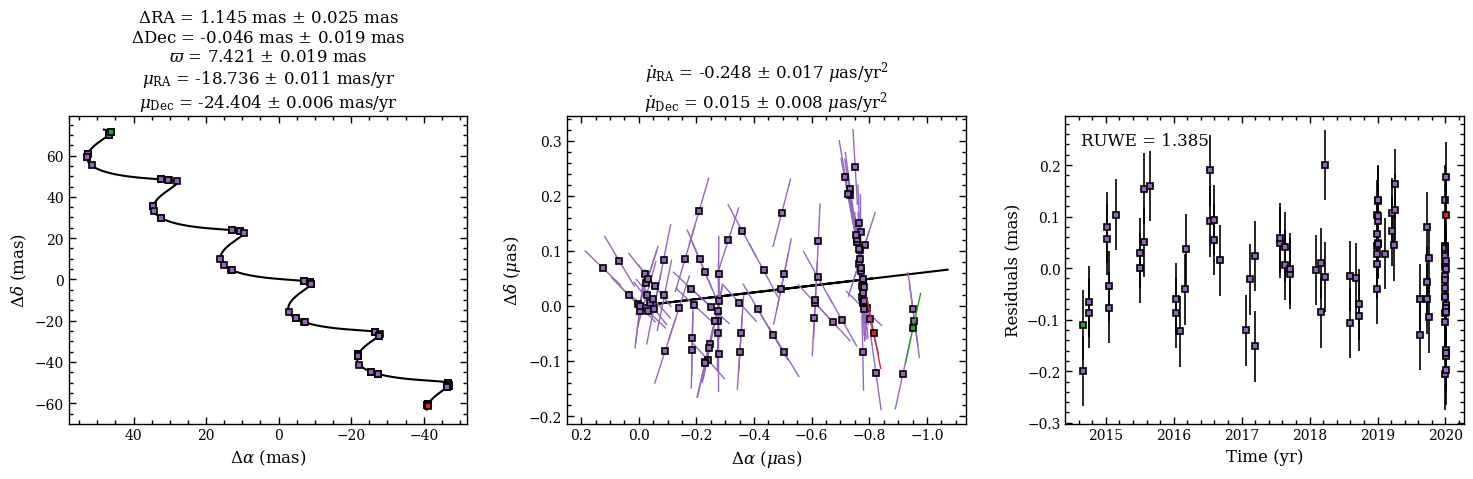

In [11]:
results = leastsq.accel_7param(plot_file='plot.png')

The RUWE is 1.3 when including the acceleration and the significance on $\frac{d \mu}{dt}$ is high. Let's check if the data also warrants including the acceleration derivative, so the second-order derivative of the proper motion.


--------------------------
Binary star (9 parameters)
--------------------------

Reduced chi^2 = 1.166
RUWE = 1.080
F2 estimator = 1.098
Inflation factor = 1.084
Significance dmu/dt = 17.091
Significance d^2mu/d^2t = 8.041

Best-fit parameters:
   - RA offset = 1.141 +/- 0.023 mas
   - Dec offset = -0.006 +/- 0.018 mas
   - Parallax = 7.410 +/- 0.017 mas
   - mu in RA = -18.749 +/- 0.025 mas/yr
   - mu in Dec = -24.519 +/- 0.015 mas/yr
   - dmu/dt in RA = -0.261 +/- 0.016 mas/yr^2
   - dmu/dt in Dec = 0.004 +/- 0.008 mas/yr^2
   - d^2mu/d^2t in RA = 0.016 +/- 0.033 mas/yr^3
   - d^2mu/d^2t in Dec = 0.124 +/- 0.016 mas/yr^3
   - PM acceleration in RA (mas/yr^2) = -0.261
   - PM acceleration in Dec (mas/yr^2) = 0.004
   - PM acceleration derivative in RA (mas/yr^3) = 0.016
   - PM acceleration derivative in Dec (mas/yr^3) = 0.124
   - PM acceleration in RA (mas/yr^2) = -0.261
   - PM acceleration in Dec (mas/yr^2) = 0.004
   - PM acceleration derivative in RA (mas/yr^3) = 0.016
   - PM

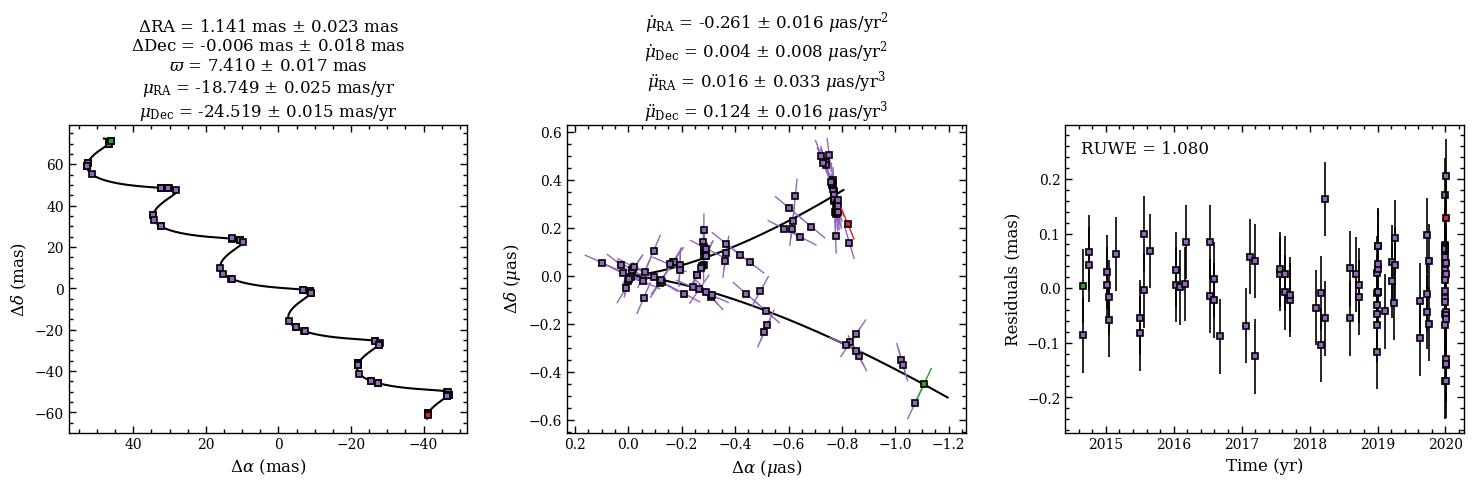

In [12]:
results = leastsq.accel_9param(plot_file='res_9param.png')

The RUWE decreased to 1.0 and the second-order proper motion derivative is quite well constrained.